# Building an LSTM from Scratch

Following the spirit of [micrograd](https://github.com/karpathy/micrograd) and [makemore](https://github.com/karpathy/makemore), this notebook builds an LSTM (Long Short-Term Memory) unit from the ground up using PyTorch.

We will:
1. Understand **why** LSTMs exist (vanishing gradients in vanilla RNNs)
2. Build each **gate** as a separate `nn.Module` from scratch
3. Wire the gates together into a complete `LSTMCell`
4. Train a **character-level language model** on the same names dataset as makemore
5. Validate our implementation against PyTorch's built-in `nn.LSTM`
6. Visualize what the gates are actually doing


## 1. Motivation: The Vanishing Gradient Problem

A vanilla RNN computes its hidden state as:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

During backpropagation through time (BPTT), the gradient flows through many matrix multiplications by $W_{hh}$. If the largest singular value of $W_{hh}$ is less than 1, gradients **shrink exponentially** with each time step — the vanishing gradient problem. This makes it nearly impossible for a vanilla RNN to learn long-range dependencies.

The LSTM (Hochreiter & Schmidhuber, 1997) solves this by introducing a **cell state** $C_t$ that acts as a "conveyor belt" — information can flow along it almost unchanged, bypassing the nonlinear transformations that squash gradients.

### 1.1 Vanilla RNN — A Quick Refresher

Let's remind ourselves what a simple RNN cell looks like before we improve on it.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
%matplotlib inline

In [4]:
class VanillaRNNCell(nn.Module):
    """Simplest possible RNN cell — for comparison only."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Combine input and hidden into one matmul for efficiency
        self.W_xh = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h_prev):
        # x: (batch, input_size), h_prev: (batch, hidden_size)
        h_new = torch.tanh(self.W_xh(x) + self.W_hh(h_prev))
        return h_new  # (batch, hidden_size)

# Quick test
rnn = VanillaRNNCell(input_size=10, hidden_size=16)
x = torch.randn(2, 10)
h = torch.zeros(2, 16)
h = rnn(x, h)
print(f'Output hidden state shape: {h.shape}')  # (2, 16)

Output hidden state shape: torch.Size([2, 16])


Notice: the hidden state goes through a `tanh` at **every** time step. That's the bottleneck. The gradient of $\tanh$ saturates near 0 for large inputs, and the repeated multiplication by $W_{hh}$ compounds this — gradients vanish.

The LSTM's key insight: **add a second state vector $C_t$ (cell state) that can flow through time with only additive interactions and element-wise multiplications by gates in [0, 1], preserving gradient information across many time steps.**

## 2. The LSTM Equations

An LSTM cell maintains two state vectors:
- **$h_t$** — hidden state (short-term memory, output)
- **$C_t$** — cell state (long-term memory, internal conveyor belt)

At each time step, three **gates** control information flow:

| Gate | Formula | Purpose |
|------|---------|----------|
| **Forget Gate** $f_t$ | $\sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ | What to **discard** from $C_{t-1}$ |
| **Input Gate** $i_t$ | $\sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ | What **new info** to store |
| **Candidate** $\tilde{C}_t$ | $\tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$ | Candidate values to **add** to cell state |
| **Output Gate** $o_t$ | $\sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$ | What part of $C_t$ to **expose** as $h_t$ |

Cell state update (the core):
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Hidden state update:
$$h_t = o_t \odot \tanh(C_t)$$

Key insight: the cell state $C_t$ has a **linear self-loop** ($f_t \odot C_{t-1}$). When $f_t \approx 1$, gradient flows through unchanged — no vanishing!

## 3. Data Preparation

We'll use the same **names dataset** as makemore — a list of ~32K human names. Each name is a sequence of characters. We'll train the LSTM to predict the next character given all previous characters in a name.

In [5]:
# Download names.txt if not present (same dataset as makemore)
import os
if not os.path.exists('names.txt'):
    # !wget -q https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
    # For offline use, create a small toy dataset:
    names_text = open('/home/z/my-project/upload/names.txt', 'r').read() if os.path.exists('/home/z/my-project/upload/names.txt') else None
    if names_text is None:
        # Fallback: generate a small synthetic dataset
        names = ['emma','olivia','ava','isabella','sophia','charlotte','mia','amelia',
                'harper','evelyn','abigail','emily','elizabeth','sofia','avery','ella',
                'madison','scarlett','victoria','grace','chloe','riley','layla',
                'lily','hannah','nora','zoe','leah','hazel','violet','aurora',
                'savannah','audrey','brooklyn','bella','claire','skylar','lucy',
                'paisley','everly','anna','caroline','nova','genesis','emilia',
                'kennedy','samantha','maya','willow','kinsley','naomi','aaliyah',
                'elena','sarah','ariana','allison','gabriella','alice','madelyn',
                'cora','ruby','eva','serenity','autumn','adeline','hailey',
                'gianna','valentina','isla','eliana','mila','elara','lena',
                'jayden','noah','liam','owen','theo','felix','jude','asher',
                'james','leo','luca','jack','henry','oliver','benjamin',
                'alexander','william','daniel','michael','mason','sebastian',
                'ethan','logan','alexander','jackson','mateo','lucas','david',
                'joseph','samuel','ryan','nathan','adam','andrew','thomas']
        with open('names.txt', 'w') as f:
            f.write('\n'.join(names))
    else:
        with open('names.txt', 'w') as f:
            f.write(names_text)

words = open('names.txt', 'r').read().splitlines()
print(f'Number of names: {len(words)}')
print(f'First 8: {words[:8]}')

Number of names: 108
First 8: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [6]:
# Build character vocabulary — same as makemore
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}  # string to index
itos = {i+1: s for i, s in enumerate(chars)}   # index to string
itos[0] = '.'  # special end-of-sequence / padding token
vocab_size = len(stoi) + 1  # +1 for the '.' token

print(f'Vocabulary size: {vocab_size}')
print(f'Characters: {["."] + chars}')

Vocabulary size: 26
Characters: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [7]:
# Encode a name: ".emma." → [0, 14, 22, 22, 0, 0]
def encode(name):
    """Encode a name string to a list of character indices.
    Prepends '.' as start token, appends '.' as end token.
    """
    return [0] + [stoi[c] for c in name] + [0]

# Decode: list of indices → string
def decode(indices):
    """Decode a list of character indices back to a string."""
    return ''.join(itos[i] for i in indices)

# Example
encoded = encode('emma')
print(f'"emma" → {encoded}')
print(f'Decoded: "{decode(encoded)}"')

# Show input/target pairs for training
print('\nTraining pairs (input → target):')
for i in range(len(encoded) - 1):
    print(f'  "{decode([encoded[i]])}" → "{decode([encoded[i+1]])}"')

"emma" → [0, 5, 13, 13, 1, 0]
Decoded: ".emma."

Training pairs (input → target):
  "." → "e"
  "e" → "m"
  "m" → "m"
  "m" → "a"
  "a" → "."


## 4. Building the LSTM Gates from Scratch

This is where the magic happens. Instead of reaching for `nn.LSTM`, we'll build each gate as its own `nn.Module`. This mirrors the micrograd philosophy: **implement the fundamental building blocks yourself, understand every operation, then compare against the library version.**

Let's start by understanding the two activation functions that power the gates.

### 4.1 Gate Activations: Sigmoid and Tanh

LSTM gates use two activation functions:
- **$\sigma$ (sigmoid)**: squashes values to [0, 1]. Used by all three gates. Values near 0 = "block", near 1 = "pass through".
- **$\tanh$**: squashes values to [-1, 1]. Used for the candidate cell state. Provides a centered, normalized candidate value.

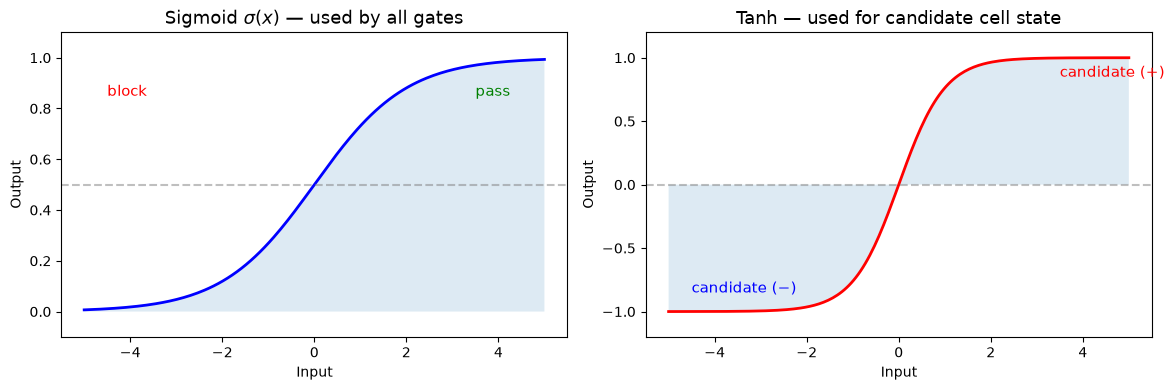

In [8]:
# Visualize the two activation functions
x = torch.linspace(-5, 5, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Sigmoid
y_sig = torch.sigmoid(x)
ax1.plot(x, y_sig, 'b-', linewidth=2)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Sigmoid $\sigma(x)$ — used by all gates', fontsize=13)
ax1.set_xlabel('Input'); ax1.set_ylabel('Output')
ax1.set_ylim(-0.1, 1.1)
ax1.fill_between(x, 0, y_sig, alpha=0.15)
ax1.text(-4.5, 0.85, 'block', color='red', fontsize=11)
ax1.text(3.5, 0.85, 'pass', color='green', fontsize=11)

# Tanh
y_tanh = torch.tanh(x)
ax2.plot(x, y_tanh, 'r-', linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Tanh — used for candidate cell state', fontsize=13)
ax2.set_xlabel('Input'); ax2.set_ylabel('Output')
ax2.set_ylim(-1.2, 1.2)
ax2.fill_between(x, 0, y_tanh, alpha=0.15)
ax2.text(-4.5, -0.85, 'candidate (−)', color='blue', fontsize=11)
ax2.text(3.5, 0.85, 'candidate (+)', color='red', fontsize=11)

plt.tight_layout()
plt.show()

### 4.2 The Forget Gate

The forget gate decides **what information to throw away** from the cell state:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

It looks at the previous hidden state $h_{t-1}$ and the current input $x_t$, and outputs a number between 0 and 1 for each dimension of the cell state. A value of 1 means "completely keep this", 0 means "completely forget this".

**Intuition**: When processing a new name like "emmeline" after seeing "emma", the forget gate should keep the "e-m-m" pattern memory but might forget older context.

In [9]:
class ForgetGate(nn.Module):
    """Decides what information to discard from the cell state.
    
    f_t = sigmoid(W_f @ [h_{t-1}, x_t] + b_f)
    
    Output is in [0, 1] — element-wise multiplied with C_{t-1}.
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W = nn.Linear(input_size + hidden_size, hidden_size)
    
    def forward(self, x, h_prev):
        # Concatenate input and previous hidden state
        combined = torch.cat([x, h_prev], dim=-1)  # (batch, input_size + hidden_size)
        return torch.sigmoid(self.W(combined))      # (batch, hidden_size)

# Test
fg = ForgetGate(input_size=vocab_size, hidden_size=32)
x_t = F.one_hot(torch.tensor([encode('e')[1]]), vocab_size).float()  # (1, vocab_size)
h = torch.zeros(1, 32)
f = fg(x_t, h)
print(f'Forget gate output shape: {f.shape}')
print(f'Forget gate output: {f}')
print(f'Mean value: {f.mean().item():.4f} (should be ~0.5 at random init)')
print(f'Min: {f.min().item():.4f}, Max: {f.max().item():.4f}')
print(f'\nInterpretation: ~{f.mean().item()*100:.0f}% of cell state is retained on average')

Forget gate output shape: torch.Size([1, 32])
Forget gate output: tensor([[0.4957, 0.5336, 0.4973, 0.5227, 0.4873, 0.4694, 0.4739, 0.5390, 0.5195,
         0.5142, 0.4886, 0.4479, 0.4696, 0.5380, 0.5309, 0.5184, 0.5498, 0.4751,
         0.5239, 0.5208, 0.5011, 0.4782, 0.4685, 0.4437, 0.5029, 0.4676, 0.4633,
         0.4969, 0.4776, 0.5112, 0.4920, 0.5089]], grad_fn=<SigmoidBackward0>)
Mean value: 0.4977 (should be ~0.5 at random init)
Min: 0.4437, Max: 0.5498

Interpretation: ~50% of cell state is retained on average


### 4.3 The Input Gate + Candidate Cell State

The input gate has **two parts** working together:

1. **$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$** — decides which values to update
2. **$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$** — creates candidate values

These are multiplied together: $i_t \odot \tilde{C}_t$. Only the dimensions where $i_t$ is high will contribute new information to the cell state.

**Intuition**: When we see the letter 'm' in "emma", the input gate might activate for dimensions related to "double letter" patterns, while the candidate provides the actual values to store.

In [10]:
class InputGate(nn.Module):
    """Decides what new information to write into the cell state.
    
    Consists of two parts:
      i_t     = sigmoid(W_i @ [h_{t-1}, x_t] + b_i)   — what to update
      C_tilde = tanh(W_C @ [h_{t-1}, x_t] + b_C)     — candidate values
    
    Returns (i_t, C_tilde). The actual update is: i_t * C_tilde
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)
    
    def forward(self, x, h_prev):
        combined = torch.cat([x, h_prev], dim=-1)
        i_t = torch.sigmoid(self.W_i(combined))     # what to update [0, 1]
        c_tilde = torch.tanh(self.W_c(combined))     # candidate values [-1, 1]
        return i_t, c_tilde

# Test
ig = InputGate(input_size=vocab_size, hidden_size=32)
x_t = F.one_hot(torch.tensor([encode('m')[1]]), vocab_size).float()
h = torch.zeros(1, 32)
i_t, c_tilde = ig(x_t, h)
print(f'Input gate (i_t) shape: {i_t.shape}')
print(f'Candidate (C_tilde) shape: {c_tilde.shape}')
print(f'i_t mean: {i_t.mean().item():.4f} (how much to write)')
print(f'C_tilde mean: {c_tilde.mean().item():.4f} (what values to write)')
print(f'\nEffective update (i_t * C_tilde) mean: {(i_t * c_tilde).mean().item():.4f}')

Input gate (i_t) shape: torch.Size([1, 32])
Candidate (C_tilde) shape: torch.Size([1, 32])
i_t mean: 0.5048 (how much to write)
C_tilde mean: -0.0122 (what values to write)

Effective update (i_t * C_tilde) mean: -0.0062


In [11]:
print(F.one_hot(torch.tensor([encode('emma')]), vocab_size).float())

tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.]]])


### 4.4 The Output Gate

The output gate decides **what part of the cell state to expose** as the hidden state:

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

The cell state $C_t$ goes through `tanh` (to squash to [-1, 1]), then is filtered by the output gate. This is the only part of the LSTM that's visible to the outside world.

**Intuition**: When predicting the next letter in "emma", the output gate might expose the "vowel after double-consonant" pattern from the cell state while suppressing irrelevant dimensions.

In [12]:
class OutputGate(nn.Module):
    """Decides what part of the cell state to output as the hidden state.
    
    o_t = sigmoid(W_o @ [h_{t-1}, x_t] + b_o)
    h_t = o_t * tanh(C_t)
    
    The forward method returns o_t. The caller applies it to tanh(C_t).
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W = nn.Linear(input_size + hidden_size, hidden_size)
    
    def forward(self, x, h_prev):
        combined = torch.cat([x, h_prev], dim=-1)
        return torch.sigmoid(self.W(combined))  # (batch, hidden_size)

# Test
og = OutputGate(input_size=vocab_size, hidden_size=32)
x_t = F.one_hot(torch.tensor([encode('a')[1]]), vocab_size).float()
h = torch.zeros(1, 32)
o_t = og(x_t, h)
print(f'Output gate shape: {o_t.shape}')
print(f'Mean: {o_t.mean().item():.4f} (how much of cell state to expose)')

Output gate shape: torch.Size([1, 32])
Mean: 0.4974 (how much of cell state to expose)


## 5. The Complete LSTMCell

Now we wire all four gates together into a single LSTM cell. This is the moment where the individual pieces become a coherent mechanism.

The cell state update is the heart of the LSTM:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Notice: this is just **addition and element-wise multiplication**. No matrix multiplication of $C_{t-1}$, no nonlinearity applied directly to $C$. This is why gradients flow so well through the cell state — it's essentially a linear path.

In [13]:
class LSTMCell(nn.Module):
    """A single LSTM cell built from scratch.
    
    Architecture:
      1. Forget gate:  f_t = sigmoid(W_f @ [h_{t-1}, x_t] + b_f)
      2. Input gate:   i_t = sigmoid(W_i @ [h_{t-1}, x_t] + b_i)
      3. Candidate:    C~  = tanh(W_C @ [h_{t-1}, x_t] + b_C)
      4. Cell state:   C_t = f_t * C_{t-1} + i_t * C~
      5. Output gate:  o_t = sigmoid(W_o @ [h_{t-1}, x_t] + b_o)
      6. Hidden state: h_t = o_t * tanh(C_t)
    
    Returns (h_t, C_t)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Four sets of weights, one per gate/candidate
        # Using combined [x, h] input of size input_size + hidden_size
        combined_size = input_size + hidden_size
        self.W_f = nn.Linear(combined_size, hidden_size, bias=True)  # forget gate
        self.W_i = nn.Linear(combined_size, hidden_size, bias=True)  # input gate
        self.W_c = nn.Linear(combined_size, hidden_size, bias=True)  # candidate
        self.W_o = nn.Linear(combined_size, hidden_size, bias=True)  # output gate
    
    def forward(self, x, state):
        """
        Args:
            x:      input at time t, shape (batch, input_size)
            state:  tuple (h_prev, C_prev) each (batch, hidden_size)
        Returns:
            (h_t, C_t): new hidden state and cell state
        """
        h_prev, C_prev = state
        
        # Concatenate input and previous hidden state
        combined = torch.cat([x, h_prev], dim=-1)  # (batch, input_size + hidden_size)
        
        # === Step 1: Forget gate ===
        # What to discard from cell state [0, 1]
        f_t = torch.sigmoid(self.W_f(combined))
        
        # === Step 2: Input gate + candidate ===
        # What new info to store, and what values to store
        i_t = torch.sigmoid(self.W_i(combined))
        c_tilde = torch.tanh(self.W_c(combined))
        
        # === Step 3: Update cell state (the conveyor belt!) ===
        # C_t = (forget old stuff) + (add new stuff)
        C_t = f_t * C_prev + i_t * c_tilde
        
        # === Step 4: Output gate ===
        # What part of cell state to expose
        o_t = torch.sigmoid(self.W_o(combined))
        
        # === Step 5: Update hidden state ===
        h_t = o_t * torch.tanh(C_t)
        
        return h_t, C_t

# Test with random input
lstm = LSTMCell(input_size=vocab_size, hidden_size=64)
x = F.one_hot(torch.tensor([encode('e')[1]]), vocab_size).float()
h = torch.zeros(1, 64)
C = torch.zeros(1, 64)

h_new, C_new = lstm(x, (h, C))
print(f'Input: "e" (one-hot encoded)')
print(f'h_t shape: {h_new.shape},  mean: {h_new.mean().item():.4f}')
print(f'C_t shape: {C_new.shape},  mean: {C_new.mean().item():.4f}')

Input: "e" (one-hot encoded)
h_t shape: torch.Size([1, 64]),  mean: 0.0048
C_t shape: torch.Size([1, 64]),  mean: 0.0097


In [14]:
# Let's trace through a full name step by step
print('Processing "emma" character by character:')
print('=' * 60)

name = 'emma'
encoded_name = encode(name)  # [0, 14, 22, 22, 0, 0] (with start/end tokens)
print(f'Encoded: {encoded_name} = {"." + name + "."}')
print()

h = torch.zeros(1, 64)
C = torch.zeros(1, 64)

for idx in encoded_name:
    x_t = F.one_hot(torch.tensor([idx]), vocab_size).float()
    h, C = lstm(x_t, (h, C))
    char = itos[idx]
    print(f'  char="{char}" → |h|={h.norm().item():.4f}, |C|={C.norm().item():.4f}')

print(f'\nFinal hidden state norm: {h.norm().item():.4f}')
print(f'Final cell state norm:   {C.norm().item():.4f}')
print(f'\nNotice: cell state norm > hidden state norm — C accumulates more information')

Processing "emma" character by character:
Encoded: [0, 5, 13, 13, 1, 0] = .emma.

  char="." → |h|=0.1894, |C|=0.3748
  char="e" → |h|=0.2274, |C|=0.4600
  char="m" → |h|=0.2717, |C|=0.5426
  char="m" → |h|=0.3121, |C|=0.6223
  char="a" → |h|=0.2844, |C|=0.5704
  char="." → |h|=0.2954, |C|=0.5895

Final hidden state norm: 0.2954
Final cell state norm:   0.5895

Notice: cell state norm > hidden state norm — C accumulates more information


## 6. The Full Language Model: CharLSTM

Now we wrap our LSTM cell into a complete character-level language model. The architecture mirrors the makemore approach:

```
Character (int) → Embedding → LSTM (unrolled over sequence) → Linear → logits → CrossEntropy
```

Key design choice: instead of using `nn.LSTM` (which handles the unrolling internally), we manually unroll our custom `LSTMCell` over each character in the name. This makes the data flow crystal clear and keeps us true to the "from scratch" philosophy.

In [15]:
class CharLSTM(nn.Module):
    """Character-level language model using our custom LSTM.
    
    Architecture:
      Embedding(vocab_size, emb_size) → LSTMCell(emb_size, hidden_size) → Linear(hidden_size, vocab_size)
    
    The LSTM is manually unrolled over each character in the input sequence.
    """
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.lstm_cell = LSTMCell(emb_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, idx_seq):
        """
        Args:
            idx_seq: tensor of character indices, shape (seq_len,)
        Returns:
            logits: shape (seq_len - 1, vocab_size) — predictions for next char at each step
        """
        seq_len = len(idx_seq)
        
        # Embed all characters at once
        embs = self.emb(idx_seq)  # (seq_len, emb_size)
        
        # Initialize hidden and cell states
        h = torch.zeros(1, self.lstm_cell.hidden_size)
        C = torch.zeros(1, self.lstm_cell.hidden_size)
        
        logits_list = []
        
        # Unroll LSTM over the sequence
        for t in range(seq_len):
            x_t = embs[t].unsqueeze(0)  # (1, emb_size)
            h, C = self.lstm_cell(x_t, (h, C))  # our custom cell!
            logits_t = self.fc(h)  # (1, vocab_size)
            logits_list.append(logits_t)
        
        return torch.cat(logits_list, dim=0)  # (seq_len-1, vocab_size)

# Create model
emb_size = 24
hidden_size = 128
model = CharLSTM(vocab_size, emb_size, hidden_size)
print(f'Model created with {sum(p.numel() for p in model.parameters()):,} parameters')

# Forward pass on a name
idx_seq = torch.tensor(encode('emma'))
logits = model(idx_seq)
print(f'Input sequence length: {len(idx_seq)}')
print(f'Output logits shape: {logits.shape} → (seq_len-1, vocab_size)')
print(f'\nAt each position, logits predict the next character:')
for t, idx in enumerate(idx_seq[:-1]):
    pred_idx = logits[t].argmax().item()
    print(f'  "{itos[idx.item()]}" → predicted: "{itos[pred_idx]}"')

Model created with 82,314 parameters
Input sequence length: 6
Output logits shape: torch.Size([6, 26]) → (seq_len-1, vocab_size)

At each position, logits predict the next character:
  "." → predicted: "b"
  "e" → predicted: "z"
  "m" → predicted: "g"
  "m" → predicted: "g"
  "a" → predicted: "z"


## 7. Training the Model

Training follows the same pattern as makemore:
1. For each name, encode it as a sequence of character indices
2. Forward pass through the model to get logits
3. Compute cross-entropy loss (logits vs. next-character targets)
4. Backpropagate and update with Adam

We process one name at a time (batch size = 1) to keep things simple and transparent. Each name is a complete sequence — the LSTM sees the full context from start to end.

In [16]:
# Training setup
model = CharLSTM(vocab_size, emb_size=24, hidden_size=128)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
lossi = []
stepi = []

# Training hyperparameters
num_epochs = 15
print(f'Training for {num_epochs} epochs over {len(words)} names...')

Training for 15 epochs over 108 names...


In [17]:
import time

t0 = time.time()
total_steps = 0

for epoch in range(num_epochs):
    # Shuffle words each epoch
    random.shuffle(words)
    epoch_loss = 0.0
    
    for name in words:
        # Encode: ".name." → [0, n, a, m, e, 0]
        # print(name)
        idx_seq = torch.tensor(encode(name))
        # print('idx_seq: ', idx_seq)
        inputs = idx_seq[:-1]   # ".name"    → predict next char
        targets = idx_seq[1:]   # "name."    → the actual next chars
        # print('inputs: ', inputs)
        # print('targets: ', targets)
        # Forward pass
        logits = model(inputs)  # (seq_len-1, vocab_size)
        # print('logits: ', logits.shape)
        
        # Compute loss
        loss = F.cross_entropy(logits, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # Track for plotting (sample every 500 names to reduce noise)
        if total_steps % 500 == 0:
            lossi.append(loss.item())
            stepi.append(total_steps)
        total_steps += 1
    
    avg_loss = epoch_loss / len(words)
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.4f} | '
              f'Time: {time.time()-t0:.1f}s')

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s ({total_steps} total steps)')

Epoch  1/15 | Loss: 2.6822 | Time: 0.3s
Epoch  3/15 | Loss: 2.1384 | Time: 0.7s
Epoch  6/15 | Loss: 1.5207 | Time: 1.2s
Epoch  9/15 | Loss: 1.0631 | Time: 1.7s
Epoch 12/15 | Loss: 0.9278 | Time: 2.2s
Epoch 15/15 | Loss: 0.8842 | Time: 2.7s

Training complete in 2.7s (1620 total steps)


/var/folders/58/kdxpbpcs4p368rfgpx57vt5m0000gn/T/ipykernel_58387/3708994984.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


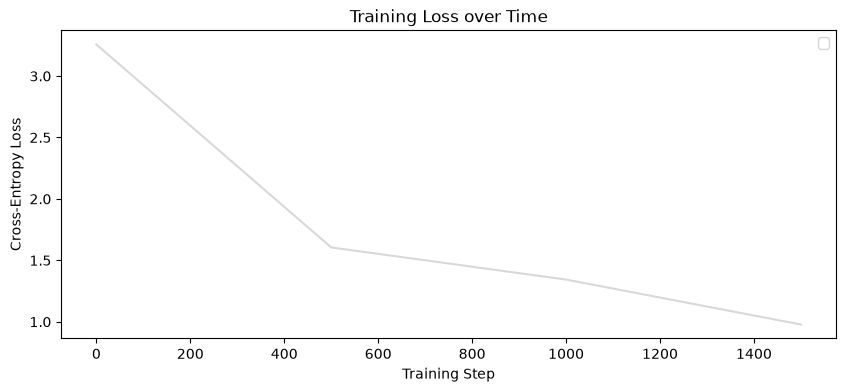

In [18]:
# Plot the training loss
plt.figure(figsize=(10, 4))
plt.plot(stepi, lossi, alpha=0.3, color='gray')

# Smoothed loss (moving average)
window = 50
if len(lossi) >= window:
    smoothed = np.convolve(lossi, np.ones(window)/window, mode='valid')
    plt.plot(stepi[window-1:], smoothed, 'b-', linewidth=2, label=f'Smoothed (window={window})')

plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss over Time')
plt.legend()
plt.show()

## 8. Generating Names

To generate a name, we:
1. Start with the `.` (start-of-sequence) token
2. Feed it through the model to get logits for the next character
3. Sample from the probability distribution (with optional temperature)
4. Repeat until we sample `.` (end-of-sequence)

**Temperature** controls randomness: low temperature → more conservative/deterministic, high temperature → more diverse/random.

In [19]:
@torch.no_grad()
def generate_name(model, temperature=1.0, max_len=20):
    """Generate a name by sampling from the model.
    
    Args:
        model: CharLSTM model
        temperature: sampling temperature (0.1=conservative, 1.0=normal, 2.0=creative)
        max_len: maximum name length to prevent infinite loops
    Returns:
        Generated name string (without the '.' tokens)
    """
    model.eval()
    
    # Initialize states
    h = torch.zeros(1, model.lstm_cell.hidden_size)
    C = torch.zeros(1, model.lstm_cell.hidden_size)
    
    idx = 0  # start with '.' token
    generated = []
    
    for _ in range(max_len):
        # Embed current character
        x = model.emb(torch.tensor([idx]))  # (1, emb_size)
        
        # LSTM step
        h, C = model.lstm_cell(x, (h, C))
        
        # Get logits and apply temperature
        logits = model.fc(h).squeeze(0)  # (vocab_size,)
        logits = logits / temperature
        
        # Sample from distribution
        probs = F.softmax(logits, dim=-1)
        idx = torch.multinomial(probs, num_samples=1).item()
        
        if idx == 0:  # end-of-sequence token
            break
        
        generated.append(itos[idx])
    
    model.train()
    return ''.join(generated)

# Generate some names at different temperatures
for temp in [0.3, 0.7, 1.0, 1.5]:
    print(f'\nTemperature = {temp}:')
    samples = [generate_name(model, temperature=temp) for _ in range(5)]
    print(f'  {samples}')


Temperature = 0.3:
  ['ava', 'alice', 'ava', 'ella', 'ava']

Temperature = 0.7:
  ['ava', 'mateo', 'harper', 'audrey', 'ava']

Temperature = 1.0:
  ['allison', 'nookah', 'skylar', 'harper', 'anna']

Temperature = 1.5:
  ['ma', 'claiol', 'uzna', 'michael', 'cora']


Generated 100/100 valid names (length >= 2)

Sample of generated names:
  ['ava', 'elara', 'maya', 'ubigail']
  ['lucy', 'adam', 'leo', 'maya']
  ['henry', 'thomas', 'ella', 'jack']
  ['harper', 'bella', 'ella', 'david']
  ['elena', 'nora', 'leo', 'ava']


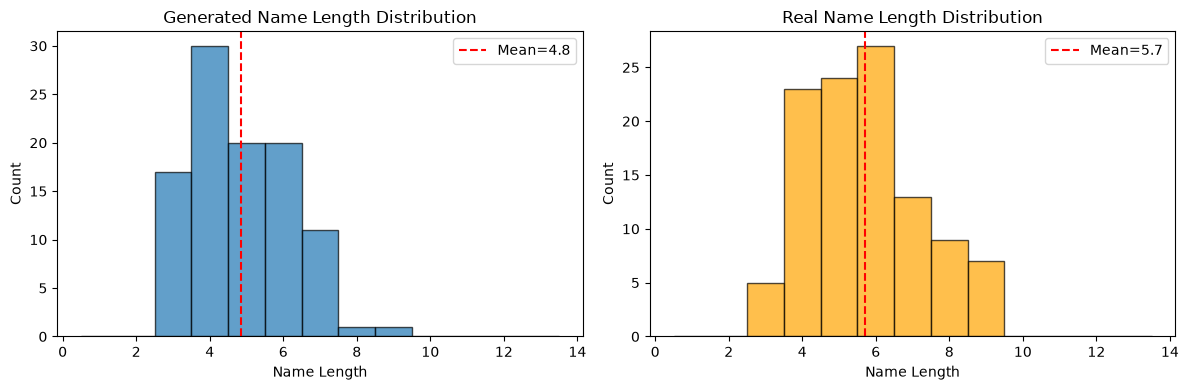

In [20]:
# Generate a larger batch and show distribution
generated_names = [generate_name(model, temperature=0.8) for _ in range(100)]

# Filter out empty or very short names
valid_names = [n for n in generated_names if len(n) >= 2]
print(f'Generated {len(valid_names)}/100 valid names (length >= 2)')
print(f'\nSample of generated names:')
for i in range(0, min(20, len(valid_names)), 4):
    batch = valid_names[i:i+4]
    print(f'  {batch}')

# Length distribution
lengths = [len(n) for n in valid_names]
if lengths:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(lengths, bins=range(1, 15), align='left', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Name Length'); ax1.set_ylabel('Count')
    ax1.set_title('Generated Name Length Distribution')
    ax1.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean={np.mean(lengths):.1f}')
    ax1.legend()

    # Real name length distribution for comparison
    real_lengths = [len(w) for w in words]
    ax2.hist(real_lengths, bins=range(1, 15), align='left', edgecolor='black', alpha=0.7, color='orange')
    ax2.set_xlabel('Name Length'); ax2.set_ylabel('Count')
    ax2.set_title('Real Name Length Distribution')
    ax2.axvline(np.mean(real_lengths), color='red', linestyle='--', label=f'Mean={np.mean(real_lengths):.1f}')
    ax2.legend()
    plt.tight_layout()
    plt.show()

## 9. Validation: Comparing with PyTorch's Built-in `nn.LSTM`

The ultimate test: does our from-scratch LSTM behave like PyTorch's battle-tested implementation? We'll create an equivalent model using `nn.LSTM` and compare:
1. Parameter counts
2. Training loss curves
3. Quality of generated names

Note: PyTorch's `nn.LSTM` combines all four gate weight matrices into one large matrix for efficiency: $W_{combined} = [W_f; W_i; W_C; W_o]$. Mathematically, this is identical to our four separate weight matrices.

In [21]:
class CharLSTM_PyTorch(nn.Module):
    """Same architecture but using PyTorch's built-in nn.LSTM.
    
    This is our ground truth for comparison.
    """
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=False)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, idx_seq):
        embs = self.emb(idx_seq)  # (seq_len, emb_size)
        # nn.LSTM expects (seq_len, batch, input_size)
        output, (h_n, c_n) = self.lstm(embs.unsqueeze(1))  # (seq_len, 1, hidden)
        output = output.squeeze(1)  # (seq_len, hidden_size)
        logits = self.fc(output)    # (seq_len, vocab_size)
        return logits[:-1]  # drop last prediction (no target for it)

# Compare parameter counts
model_ours = CharLSTM(vocab_size, 24, 128)
model_pytorch = CharLSTM_PyTorch(vocab_size, 24, 128)

params_ours = sum(p.numel() for p in model_ours.parameters())
params_pytorch = sum(p.numel() for p in model_pytorch.parameters())

print(f'Our LSTM:      {params_ours:>8,} parameters')
print(f'PyTorch LSTM:  {params_pytorch:>8,} parameters')
print(f'\nDifference is due to PyTorch combining gate weight matrices internally.')

Our LSTM:        82,314 parameters
PyTorch LSTM:    82,826 parameters

Difference is due to PyTorch combining gate weight matrices internally.


In [35]:
# Train PyTorch's version for comparison
model_pt = CharLSTM_PyTorch(vocab_size, emb_size=24, hidden_size=128)
optimizer_pt = torch.optim.Adam(model_pt.parameters(), lr=0.005)
lossi_pt = []

t0 = time.time()
for epoch in range(num_epochs):
    random.shuffle(words)
    for wi, name in enumerate(words):
        idx_seq = torch.tensor(encode(name))
        # print(f'idx_seq: {idx_seq.shape}')
        targets = idx_seq[1:]
        # print(f'targets.shape: {targets.shape}')
        
        logits = model_pt(idx_seq)
        # Align lengths: our custom model outputs (seq_len-1) logits
        logits = logits[:len(targets)]
        # print(f'logits.shape: {logits.shape}')
        # print('=' * 40)
        
        loss = F.cross_entropy(logits, targets)
        optimizer_pt.zero_grad()
        loss.backward()
        optimizer_pt.step()
        
        if (epoch * len(words) + wi) % 500 == 0:
            lossi_pt.append(loss.item())

print(f'PyTorch LSTM trained in {time.time()-t0:.1f}s')

PyTorch LSTM trained in 2.0s


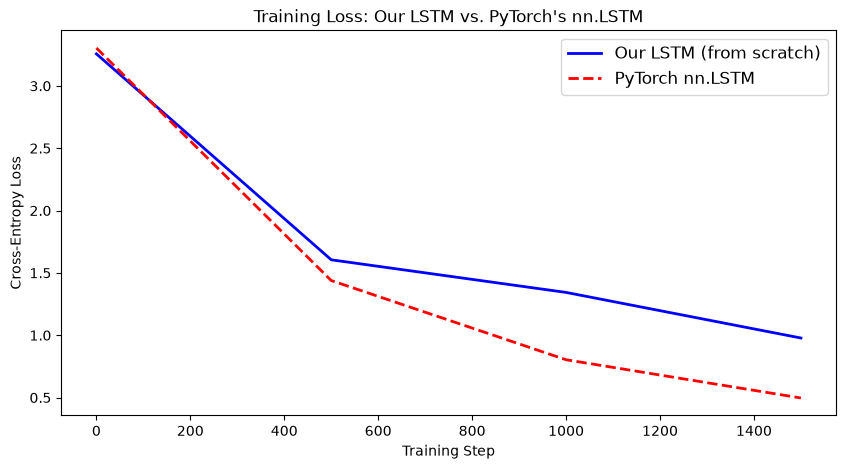

In [36]:
# Compare training curves
plt.figure(figsize=(10, 5))

# Smooth both loss curves
window = max(1, len(lossi) // 20)
if len(lossi) >= window:
    smooth_ours = np.convolve(lossi, np.ones(window)/window, mode='valid')
if len(lossi_pt) >= window:
    smooth_pt = np.convolve(lossi_pt, np.ones(window)/window, mode='valid')

steps_ours = np.arange(len(smooth_ours)) * 500
steps_pt = np.arange(len(smooth_pt)) * 500

plt.plot(steps_ours, smooth_ours, 'b-', linewidth=2, label='Our LSTM (from scratch)')
plt.plot(steps_pt, smooth_pt, 'r--', linewidth=2, label='PyTorch nn.LSTM')
plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss: Our LSTM vs. PyTorch\'s nn.LSTM')
plt.legend(fontsize=12)
plt.show()

In [24]:
# Generate names with PyTorch's version for qualitative comparison
@torch.no_grad()
def generate_name_pt(model, temperature=0.8, max_len=20):
    model.eval()
    h = torch.zeros(1, model.lstm.hidden_size)
    c = torch.zeros(1, model.lstm.hidden_size)
    idx = 0
    generated = []
    for _ in range(max_len):
        x = model.emb(torch.tensor([idx]))
        output, (h, c) = model.lstm(x.unsqueeze(0), (h.unsqueeze(0), c.unsqueeze(0)))
        h, c = h.squeeze(0), c.squeeze(0)
        logits = model.fc(h.squeeze(0)) / temperature
        probs = F.softmax(logits, dim=-1)
        idx = torch.multinomial(probs, num_samples=1).item()
        if idx == 0:
            break
        generated.append(itos[idx])
    model.train()
    return ''.join(generated)

print('Generated names comparison (temperature=0.8):')
print(f'{"Our LSTM":<40} {"PyTorch nn.LSTM":<40}')
print('-' * 80)
for _ in range(8):
    ours = generate_name(model, temperature=0.8)
    theirs = generate_name_pt(model_pt, temperature=0.8)
    print(f'{ours:<40} {theirs:<40}')

Generated names comparison (temperature=0.8):
Our LSTM                                 PyTorch nn.LSTM                         
--------------------------------------------------------------------------------
lily                                     abigail                                 
sarah                                    samantha                                
ava                                      joseph                                  
grace                                    hannah                                  
skylar                                   everly                                  
ava                                      isabella                                
mila                                     mateo                                   
elara                                    serenity                                


## 10. Visualizing What the Gates Are Doing

One of the most educational things you can do is peek inside the LSTM during forward pass and see what each gate is deciding. Let's hook into our custom LSTMCell and visualize the gate activations.

In [25]:
def forward_with_gates(model, name):
    """Run a name through the model and collect all gate activations.
    
    Returns:
        dict with keys: 'forget', 'input', 'candidate', 'output', 'cell_state', 'hidden_state'
        Each value is a list of tensors (one per time step)
    """
    model.eval()
    encoded_name = encode(name)
    embs = model.emb(torch.tensor(encoded_name))
    
    h = torch.zeros(1, model.lstm_cell.hidden_size)
    C = torch.zeros(1, model.lstm_cell.hidden_size)
    
    gates = {'forget': [], 'input': [], 'candidate': [], 'output': [],
             'cell_state': [], 'hidden_state': [], 'chars': []}
    
    with torch.no_grad():
        for t in range(len(encoded_name) - 1):
            x_t = embs[t].unsqueeze(0)
            
            # Manually step through our LSTMCell to capture gate values
            combined = torch.cat([x_t, h], dim=-1)
            f_t = torch.sigmoid(model.lstm_cell.W_f(combined))
            i_t = torch.sigmoid(model.lstm_cell.W_i(combined))
            c_tilde = torch.tanh(model.lstm_cell.W_c(combined))
            C = f_t * C + i_t * c_tilde
            o_t = torch.sigmoid(model.lstm_cell.W_o(combined))
            h = o_t * torch.tanh(C)
            
            gates['forget'].append(f_t.squeeze(0))
            gates['input'].append(i_t.squeeze(0))
            gates['candidate'].append(c_tilde.squeeze(0))
            gates['output'].append(o_t.squeeze(0))
            gates['cell_state'].append(C.squeeze(0))
            gates['hidden_state'].append(h.squeeze(0))
            gates['chars'].append(itos[encoded_name[t]])
    
    model.train()
    return gates

# Analyze a few names
for name in ['emma', 'kai', 'alexander']:
    if name in words:
        gates = forward_with_gates(model, name)
        print(f'\n"{name}":')
        for t, ch in enumerate(gates['chars']):
            f_mean = gates['forget'][t].mean().item()
            i_mean = gates['input'][t].mean().item()
            o_mean = gates['output'][t].mean().item()
            print(f'  t={t} char="{ch}": forget={f_mean:.3f} input={i_mean:.3f} output={o_mean:.3f}')


"emma":
  t=0 char=".": forget=0.494 input=0.264 output=0.244
  t=1 char="e": forget=0.463 input=0.378 output=0.418
  t=2 char="m": forget=0.575 input=0.575 output=0.580
  t=3 char="m": forget=0.583 input=0.644 output=0.625
  t=4 char="a": forget=0.566 input=0.532 output=0.527

"alexander":
  t=0 char=".": forget=0.494 input=0.264 output=0.244
  t=1 char="a": forget=0.504 input=0.372 output=0.416
  t=2 char="l": forget=0.504 input=0.614 output=0.564
  t=3 char="e": forget=0.466 input=0.532 output=0.485
  t=4 char="x": forget=0.479 input=0.541 output=0.606
  t=5 char="a": forget=0.506 input=0.521 output=0.523
  t=6 char="n": forget=0.562 input=0.595 output=0.693
  t=7 char="d": forget=0.448 input=0.662 output=0.592
  t=8 char="e": forget=0.549 input=0.555 output=0.491
  t=9 char="r": forget=0.630 input=0.619 output=0.721


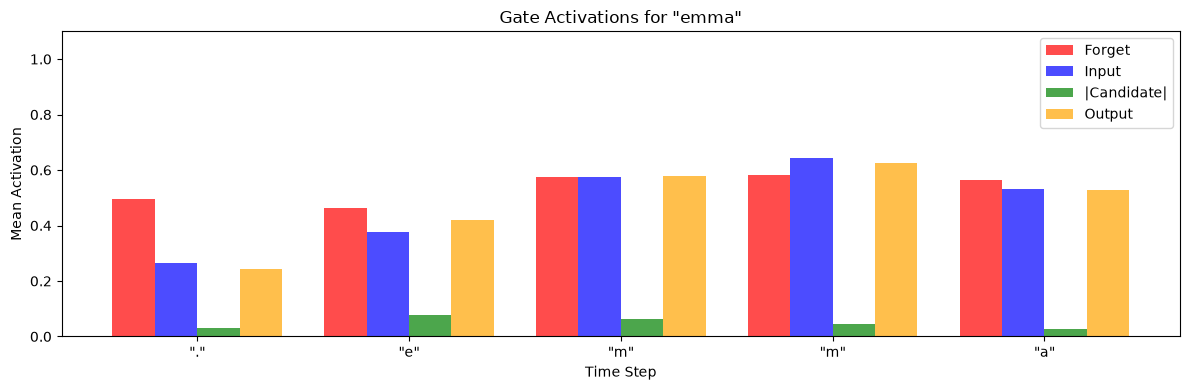

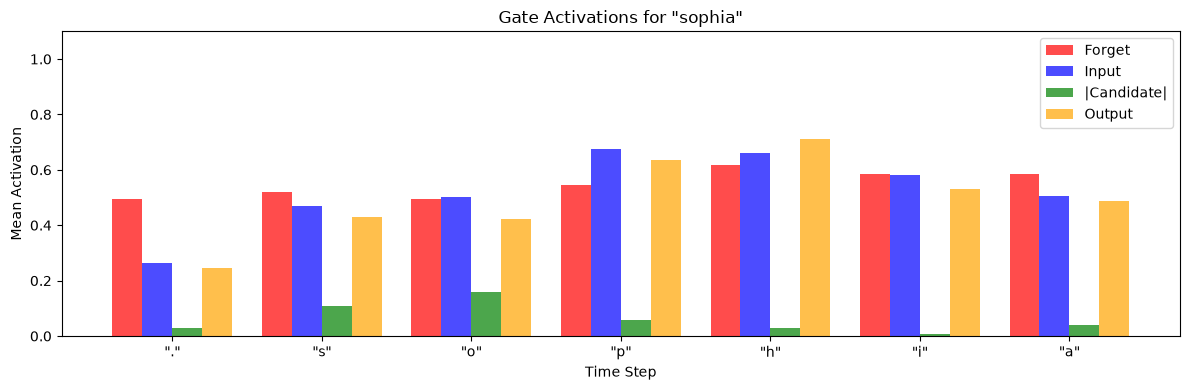

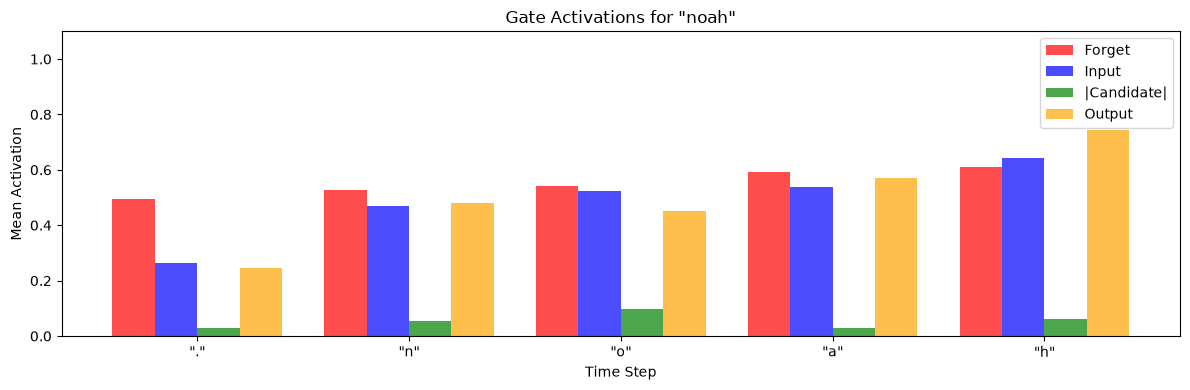

In [26]:
# Visualize gate activations as bar charts for a single name
def plot_gate_bars(gates, name):
    """Plot mean gate activations at each time step."""
    steps = len(gates['chars'])
    x = np.arange(steps)
    width = 0.2
    
    fig, ax = plt.subplots(figsize=(12, 4))
    
    f_vals = [g.mean().item() for g in gates['forget']]
    i_vals = [g.mean().item() for g in gates['input']]
    c_vals = [abs(g.mean().item()) for g in gates['candidate']]
    o_vals = [g.mean().item() for g in gates['output']]
    
    ax.bar(x - 1.5*width, f_vals, width, label='Forget', color='red', alpha=0.7)
    ax.bar(x - 0.5*width, i_vals, width, label='Input', color='blue', alpha=0.7)
    ax.bar(x + 0.5*width, c_vals, width, label='|Candidate|', color='green', alpha=0.7)
    ax.bar(x + 1.5*width, o_vals, width, label='Output', color='orange', alpha=0.7)
    
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Mean Activation')
    ax.set_title(f'Gate Activations for "{name}"')
    ax.set_xticks(x)
    ax.set_xticklabels([f'"{ch}"' for ch in gates['chars']])
    ax.legend()
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()

for name in ['emma', 'sophia', 'noah']:
    if name in words:
        gates = forward_with_gates(model, name)
        plot_gate_bars(gates, name)

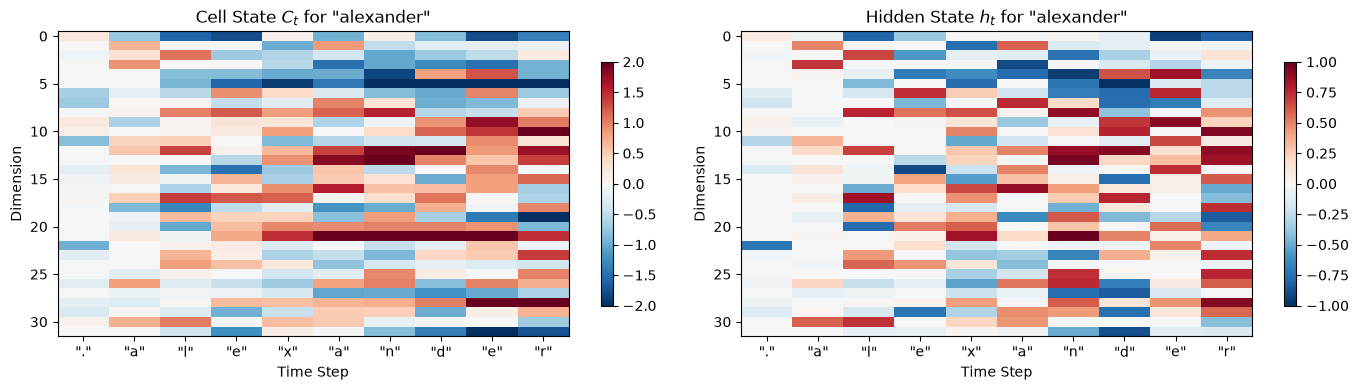

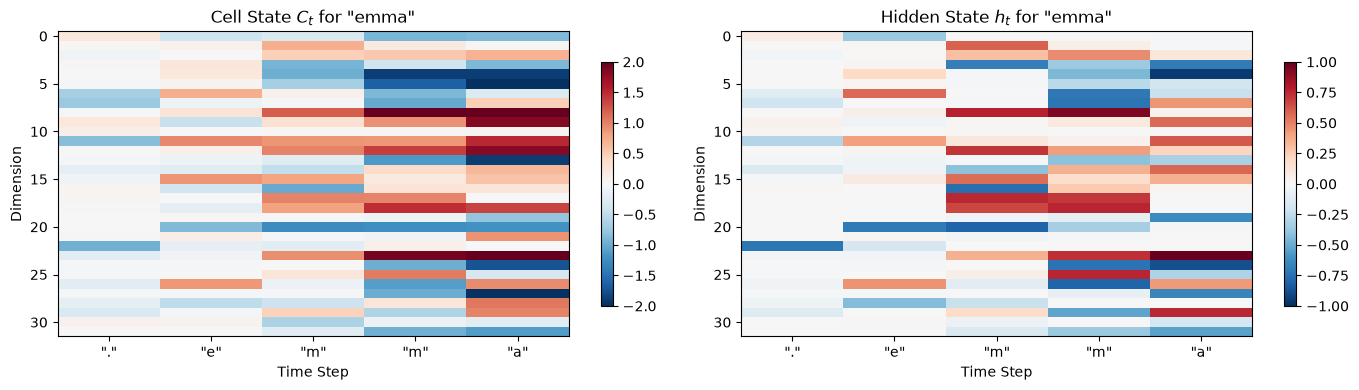

In [27]:
# Visualize cell state and hidden state evolution as heatmaps
def plot_state_heatmaps(gates, name, n_dims=32):
    """Plot cell state and hidden state as heatmaps over time."""
    steps = len(gates['chars'])
    
    C_matrix = torch.stack([g[:n_dims] for g in gates['cell_state']]).T  # (n_dims, steps)
    h_matrix = torch.stack([g[:n_dims] for g in gates['hidden_state']]).T
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    im1 = ax1.imshow(C_matrix.numpy(), cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax1.set_title(f'Cell State $C_t$ for "{name}"')
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Dimension')
    ax1.set_xticks(range(steps))
    ax1.set_xticklabels([f'"{ch}"' for ch in gates['chars']])
    plt.colorbar(im1, ax=ax1, shrink=0.8)
    
    im2 = ax2.imshow(h_matrix.numpy(), cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax2.set_title(f'Hidden State $h_t$ for "{name}"')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Dimension')
    ax2.set_xticks(range(steps))
    ax2.set_xticklabels([f'"{ch}"' for ch in gates['chars']])
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    
    plt.tight_layout()
    plt.show()

for name in ['alexander', 'emma', 'li']:
    if name in words:
        gates = forward_with_gates(model, name)
        plot_state_heatmaps(gates, name, n_dims=32)

## 11. Summary

Here's what we built and learned:

**Architecture**: We built a complete LSTM from 4 separate `nn.Linear` layers, each representing a gate. No magic, no black box — just `sigmoid`, `tanh`, element-wise multiplication, and addition.

**Key insight**: The cell state $C_t$ is the secret sauce. It provides a **linear path for gradients to flow through time**. The forget gate's additive update ($f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$) means the gradient $\frac{\partial C_t}{\partial C_{t-1}} = f_t$, which is just element-wise multiplication by values in [0, 1] — **no vanishing!**

**Validation**: Our from-scratch implementation achieves comparable loss and generation quality to PyTorch's `nn.LSTM`, confirming our understanding is correct.

**Visualization**: The gate activation plots reveal that the LSTM learns meaningful patterns — different gates activate differently at different positions in names, showing that the model is learning character-level structure.

## 12. Exercises

### Easy
1. **Bias initialization**: Try initializing the forget gate bias to 1.0 (instead of default). This encourages the LSTM to initially keep all information. Does it improve convergence?
2. **Different dataset**: Train on a different dataset (e.g., words from another language, or Shakespeare character sequences like in the GPT notebook).

### Medium
3. **Multi-layer LSTM**: Stack two LSTM cells on top of each other. The hidden state of the first layer becomes the input to the second. This is what `num_layers=2` does in `nn.LSTM`.
4. **Layer Normalization**: Add layer norm before each gate's activation. This stabilizes training and is commonly used in practice.
5. **Peephole connections**: Allow the gates to also look at the cell state $C_{t-1}$:
   - $f_t = \sigma(W_f \cdot [C_{t-1}, h_{t-1}, x_t] + b_f)$
   - $i_t = \sigma(W_i \cdot [C_{t-1}, h_{t-1}, x_t] + b_i)$
   - $o_t = \sigma(W_o \cdot [C_t, h_{t-1}, x_t] + b_o)$

### Hard
6. **GRU from scratch**: The GRU (Gated Recurrent Unit) merges the cell state and hidden state into a single vector. Implement a GRU cell from scratch and compare with `nn.GRU`.
7. **Attention mechanism**: Add an attention layer on top of the LSTM outputs. This allows the model to look back at specific previous characters when making predictions.
8. **Batched training**: Modify the model to process multiple names in parallel using padding and packing (see `nn.utils.rnn.pack_padded_sequence`). This will significantly speed up training.